# 🩸 Business Domain Analysis: Blood Donation Behavior Prediction

## 🎯 Business Objective

The goal is to **predict whether a donor will donate blood again in the future** based on their past donation history.  
This helps **blood banks and healthcare organizations** to:

- Identify **potential repeat donors**
- Improve **donor retention strategies**
- Plan **blood collection drives efficiently**
- Reduce **shortages and wastage** of blood units

---

## 📊 Data Attributes & Business Relevance

| Feature | Type | Description | Business Value |
|----------|------|-------------|----------------|
| `Recency` | Numerical | Months since the last donation | Indicates donor activity; smaller values suggest recent donors |
| `Frequency` | Numerical | Total number of donations made | Reflects donor loyalty and engagement |
| `Monetary` | Numerical | Total volume of blood donated (in c.c.) | Represents total contribution; helps assess donor commitment |
| `Time` | Numerical | Months since the first donation | Shows how long a person has been associated with the program |
| `Target` | Categorical | Whether the donor will donate again (1 = Yes, 0 = No) | Used as the target variable for classification |

---

## 💡 Business Use Cases

### 1. Donor Retention  
Predicting likely donors helps schedule **personalized reminders** and **thank-you messages** to increase engagement.

### 2. Efficient Campaign Planning  
Helps blood banks **plan drives more effectively** by focusing on regions or individuals with higher donation probability.

### 3. Resource Optimization  
Reduces the **cost and effort** of reaching inactive donors, ensuring better use of resources.

### 4. Community Health Insights  
Analyzing donation behavior supports **public health awareness** and motivates more people to become regular donors ❤️

---

## 🎯 Target Variable Analysis

- The target variable (`Target`) is **binary**, indicating whether a person will donate again or not.  
- The dataset is **imbalanced**, with fewer positive (donor) cases compared to negatives.  
- Thus, metrics like **Precision**, **Recall**, and **F1-Score** are key to evaluate the model effectively.

---

## 🧠 Modeling Considerations

- Use **classification algorithms** such as:
  - Logistic Regression  
  - Support Vector Classifier (SVC)  
  - Random Forest Classifier  
  - Gradient Boosting Classifier  
- Apply **GridSearchCV** for hyperparameter tuning.  
- Scale features (especially for SVC) for better performance.  
- Focus on **Recall** and **F1-Score** to ensure accurate identification of potential donors.  
- Evaluate models using **Accuracy**, **Precision**, **Recall**, **F1-Score**. 

---

## 🧾 Summary

| Aspect | Summary |
|--------|----------|
| **Goal** | Predict whether a donor will donate blood again |
| **Key Features** | Recency, Frequency, Monetary, Time |
| **Target** | `Target` (1 = Donor, 0 = Non-Donor) |
| **ML Type** | Supervised Classification |
| **Stakeholders** | Blood banks, healthcare organizations, NGOs |
| **Business Impact** | Better donor retention, efficient planning, and optimized blood supply management 🩸 | 

## Importing Necessary Libraries 

In [1]:
# Importing required libraries/modules 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

## Loading the Dataset 

In [2]:
data = pd.read_csv("Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv")  # Loading dataset from CSV into a pandas DataFrame 

## Basic Check 

In [3]:
data.head() # Showing first few rows for a quick glance at structure 

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


In [4]:
data.info() # Inspecting dtypes and non-null counts 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   576 non-null    int64
 1   Months since Last Donation   576 non-null    int64
 2   Number of Donations          576 non-null    int64
 3   Total Volume Donated (c.c.)  576 non-null    int64
 4   Months since First Donation  576 non-null    int64
 5   Made Donation in March 2007  576 non-null    int64
dtypes: int64(6)
memory usage: 27.1 KB


In [5]:
data.isnull().sum() # Checking for null values in the data 

Unnamed: 0                     0
Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

In [6]:
data.describe() # Getting summary statistics to understand numeric distributions 

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,374.034722,9.439236,5.427083,1356.770833,34.050347,0.239583
std,216.947773,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,0.000000,1.000000,250.000000,2.000000,0.000000
25%,183.750000,2.000000,2.000000,500.000000,16.000000,0.000000
50%,375.500000,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,562.500000,14.000000,7.000000,1750.000000,49.250000,0.000000
max,747.000000,74.000000,50.000000,12500.000000,98.000000,1.000000


### Descriptive Analysis 

The dataset contains information about blood donors, focusing on their donation behavior. Below are the insights derived from the key variables:

- **Months since Last Donation (Recency):**  
  This feature measures the time gap since a donor’s last contribution. Most donors returned within 14 months, though a few show much longer gaps, extending up to 74 months.

- **Number of Donations (Frequency):**  
  This feature indicates how many times a donor has given blood in total. About 75% of donors made 7 or fewer donations, while a small group of highly regular donors reached up to 50 donations.

- **Total Volume Donated (Monetary Equivalent):**  
  Most donors contributed 1,750 cc or less, whereas a few very frequent donors donated up to 12,500 cc, which corresponds to the maximum of 50 lifetime donations. 

- **Months since First Donation (Tenure):**  
  This feature represents how long a donor has been part of the program. Most donors have participated for up to 49 months, while a few long-term donors have been active for nearly 8 years (98 months).

- **Target (March 2007 Donation):**  
  The binary target variable indicates whether a donor donated blood in March 2007. On average, about 24% of donors made a donation during this period. 

## EDA 

### Univariate Analysis 

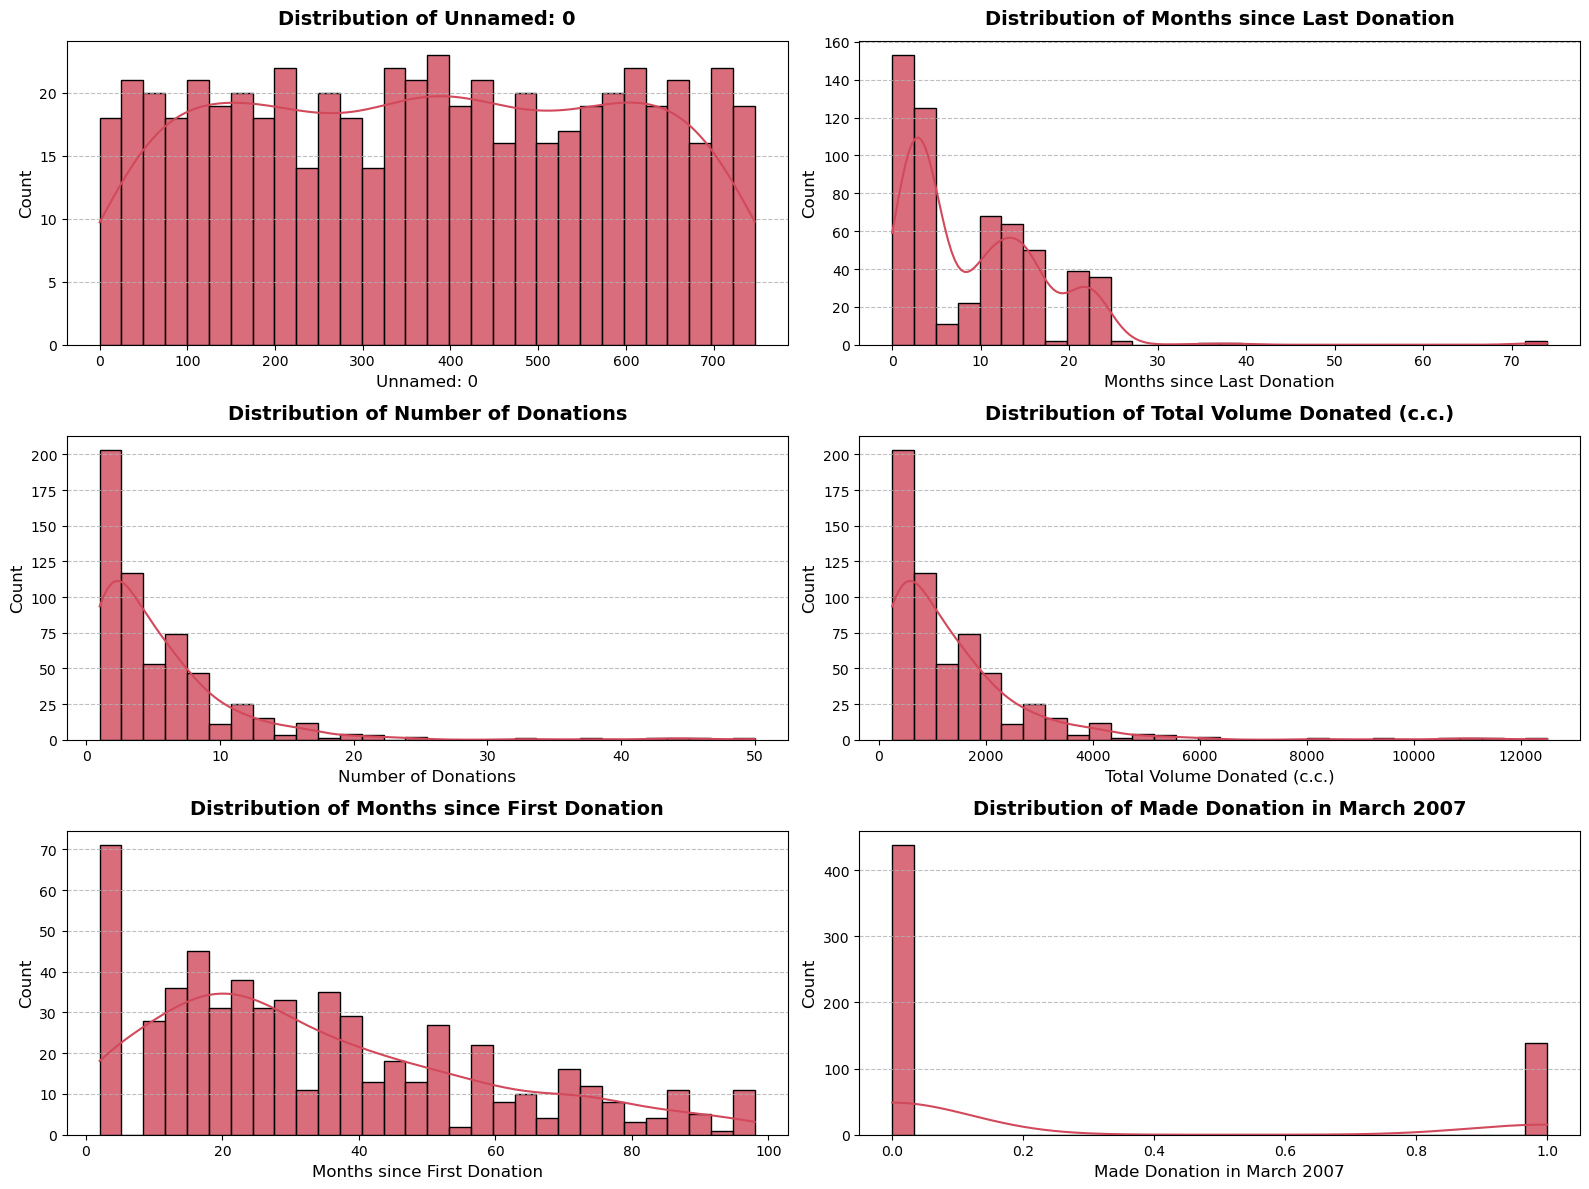

In [7]:
# Set the overall figure size
plt.figure(figsize = (16, 12))

# Select numerical columns
numerical_cols = data.select_dtypes(include = ["int", "float"]).columns  

# Loop through numerical columns and create histograms
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 2, i) 
    
    # Plot histogram with KDE line
    sns.histplot(data[col], kde = True, bins = 30, color = "#D1495B", edgecolor = "black", alpha = 0.8) 
    
    # Add titles and labels
    plt.title(f"Distribution of {col}", fontsize = 14, fontweight = "bold", pad = 12) 
    plt.xlabel(col, fontsize = 12)
    plt.ylabel("Count", fontsize = 12)
    
    # Light grid for better readability
    plt.grid(axis = "y", linestyle = "--", alpha = 0.8) 

# Adjust layout
plt.tight_layout() 
plt.show() 

### Insights 

#### 1. Months since Last Donation  
Most donors have donated recently, within the last 5 months. However, there are some donors with long gaps who haven’t donated for over 20–70 months, representing outliers.  

#### 2. Number of Donations  
The distribution is right-skewed, with most donors making fewer than 5 donations. Only a small number of highly frequent donors have contributed up to 50 times.  

#### 3. Total Volume Donated  
The total blood donated is also right-skewed. Most donors have donated less than 2,000 cc, while a few long-term donors have donated as much as 12,000 cc, which corresponds to around 50 donations.  

#### 4. Months since First Donation  
Many donors are relatively new, with their first donation occurring within the last 5 months. The distribution extends up to 100 months, indicating the presence of long-term donors, some of whom may now be inactive.  

#### 5. Made Donation in March 2007 (Target Column)  
The target column shows a class imbalance. About one-fourth (24%) of donors made a donation in March 2007, while the majority (76%) did not. This imbalance should be considered while building predictive models. 

### Bivariate Analysis 

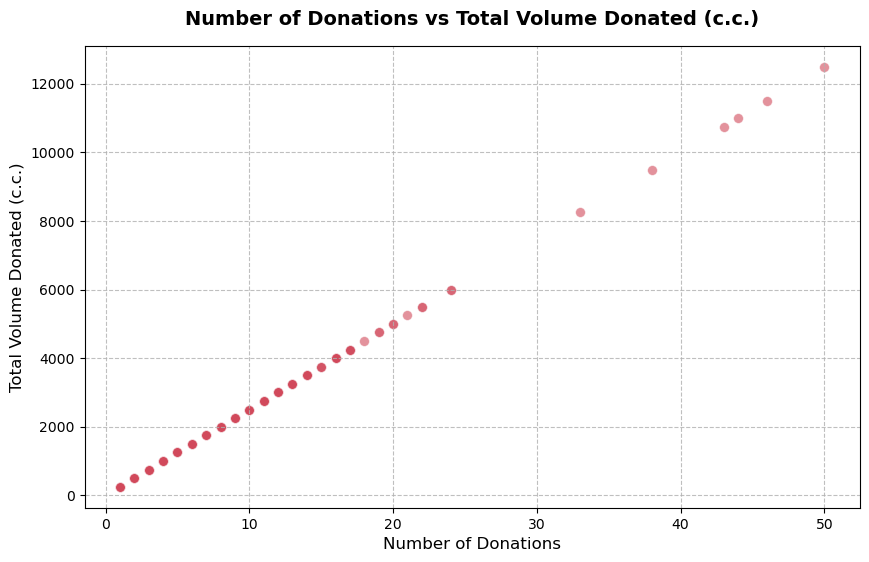

In [8]:
# Set the size of the plot 
plt.figure(figsize=(10, 6)) 

# Scatter plot
sns.scatterplot(x = data["Number of Donations"], y = data["Total Volume Donated (c.c.)"], alpha = 0.6, s = 50, color = "#D1495B") 

# Title and labels 
plt.title("Number of Donations vs Total Volume Donated (c.c.)", fontsize = 14, fontweight = "bold", pad = 15)
plt.xlabel("Number of Donations", fontsize = 12)
plt.ylabel("Total Volume Donated (c.c.)", fontsize = 12)

# Light grid for readability
plt.grid(linestyle = "--", alpha = 0.8) 

plt.show() 

#### Number of Donations vs. Total Volume Donated (c.c.) 

The graph shows a **perfect positive correlation** between the number of donations and the total volume of blood donated. As the number of donations increases, the total donated volume increases proportionally. This makes sense because each donation contributes a fixed amount of blood, so the total volume donated is essentially a multiple of the number of donations. 

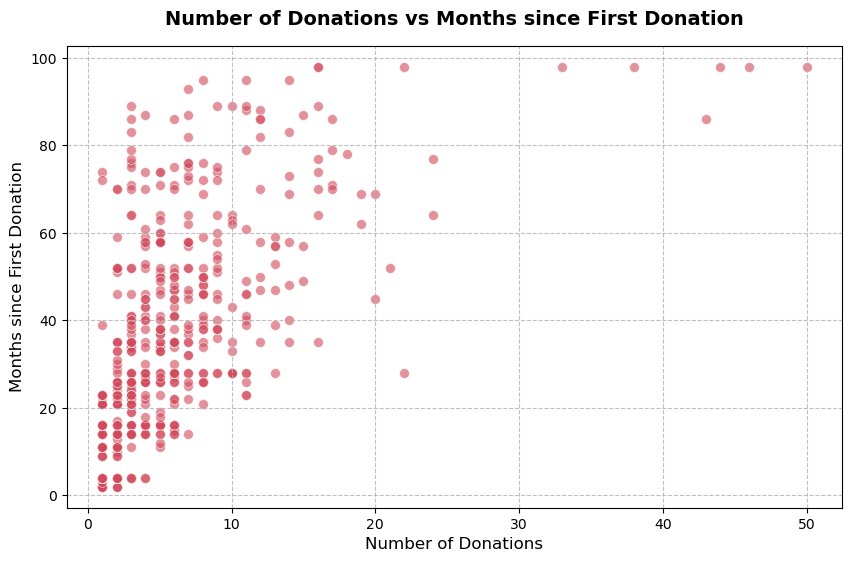

In [9]:
# Set the size of the plot 
plt.figure(figsize=(10, 6)) 

# Scatter plot
sns.scatterplot(x = data["Number of Donations"], y = data["Months since First Donation"], alpha = 0.6, s = 50, color = "#D1495B") 

# Title and labels 
plt.title("Number of Donations vs Months since First Donation", fontsize = 14, fontweight = "bold", pad = 15)
plt.xlabel("Number of Donations", fontsize = 12)
plt.ylabel("Months since First Donation", fontsize = 12)

# Light grid for readability 
plt.grid(linestyle = "--", alpha = 0.8) 

plt.show() 

#### Number of Donations vs. Months since First Donation 

There is a positive relationship between the number of donations and months since first donation. Donors who joined long ago generally have more donations, although most of them still fall under the low-frequency category (less than 10 donations). A smaller group of long-term donors stands out as highly consistent, having donated 20–50 times over the years. 

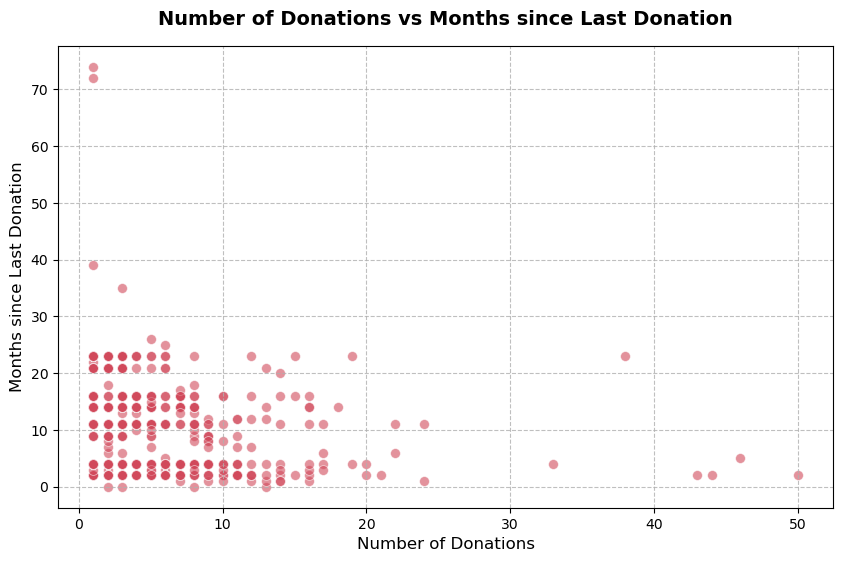

In [10]:
# Set the size of the plot 
plt.figure(figsize=(10, 6)) 

# Scatter plot
sns.scatterplot(x = data["Number of Donations"], y = data["Months since Last Donation"], alpha = 0.6, s = 50, color = "#D1495B") 

# Title and labels 
plt.title("Number of Donations vs Months since Last Donation", fontsize = 14, fontweight = "bold", pad = 15)
plt.xlabel("Number of Donations", fontsize = 12)
plt.ylabel("Months since Last Donation", fontsize = 12)

# Light grid for readability
plt.grid(linestyle = "--", alpha = 0.8) 

plt.show() 

#### Number of Donations vs. Months since Last Donation

There is no clear linear correlation between the number of donations and months since last donation. However, most donors, regardless of donation count, cluster within the last 0–10 months, representing recent activity. Donors with very few donations (1–3) are more likely to appear with long gaps of 35–70+ months, reflecting inactive candidates. On the other hand, donors with higher donation counts usually appear at shorter intervals (0–5 months), showing that frequent donors also tend to stay more active. 

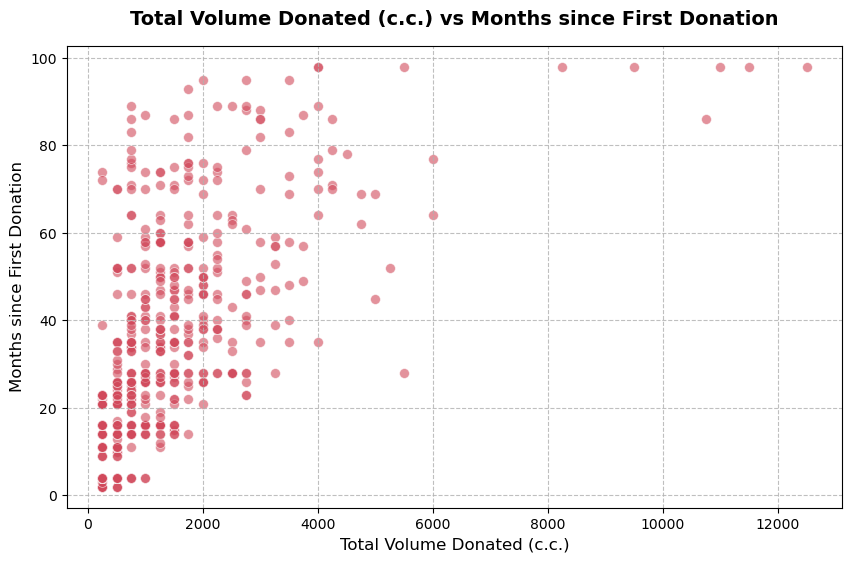

In [11]:
# Set the size of the plot 
plt.figure(figsize=(10, 6)) 

# Scatter plot
sns.scatterplot(x = data["Total Volume Donated (c.c.)"], y = data["Months since First Donation"], alpha = 0.6, s = 50, color = "#D1495B") 

# Title and labels 
plt.title("Total Volume Donated (c.c.) vs Months since First Donation", fontsize = 14, fontweight = "bold", pad = 15)
plt.xlabel("Total Volume Donated (c.c.)", fontsize = 12)
plt.ylabel("Months since First Donation", fontsize = 12)

# Light grid for readability 
plt.grid(linestyle = "--", alpha = 0.8) 

plt.show() 

#### Total Volume Donated vs. Months since First Donation 

There is a strong positive linear relationship between total volume donated and months since first donation. Long-term donors who have been part of the program for many years have contributed large volumes, up to 12,000+ cc of blood. However, there are also long-term donors with very low donated volumes, indicating rare or inactive participation. On the other hand, new donors who joined only in recent months appear with very small volumes, reflecting their first or early donations. 

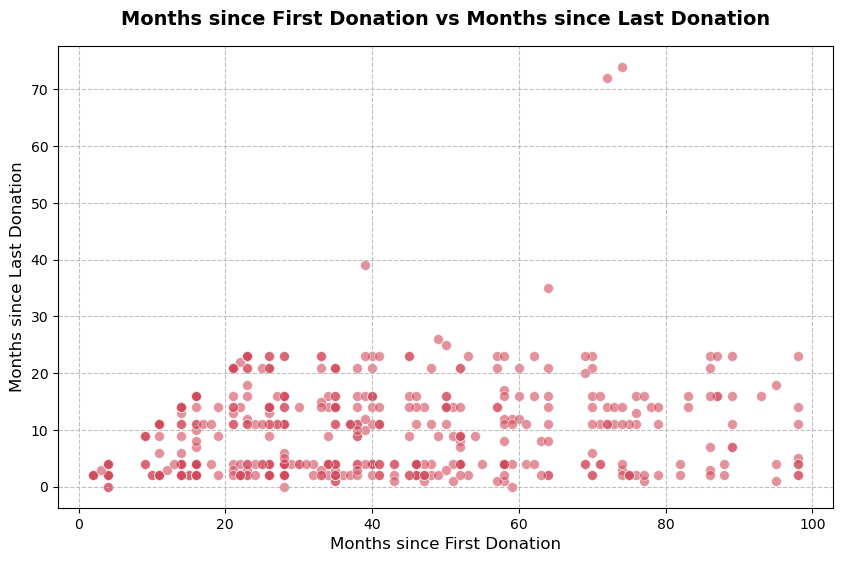

In [12]:
# Set the size of the plot 
plt.figure(figsize=(10, 6)) 

# Scatter plot
sns.scatterplot(x = data["Months since First Donation"], y = data["Months since Last Donation"], alpha = 0.6, s = 50, color = "#D1495B") 

# Title and labels 
plt.title("Months since First Donation vs Months since Last Donation", fontsize = 14, fontweight = "bold", pad = 15)
plt.xlabel("Months since First Donation", fontsize = 12)
plt.ylabel("Months since Last Donation", fontsize = 12)

# Light grid for readability 
plt.grid(linestyle = "--", alpha = 0.8) 

plt.show() 

#### Months since First Donation vs. Months since Last Donation 

Most donors, regardless of when they first joined the program, have donated recently (within the last 5 months). Donors who joined a long time ago (60–100 months) are a mixed group — some are still active with recent donations, while others are inactive, showing long gaps of 20–70+ months. Overall, there is no strong correlation between months since first donation and months since last donation, as donor activity varies widely.

### Multivariate Analysis 

#### Checking for Correlation(Correlation Matrix) 

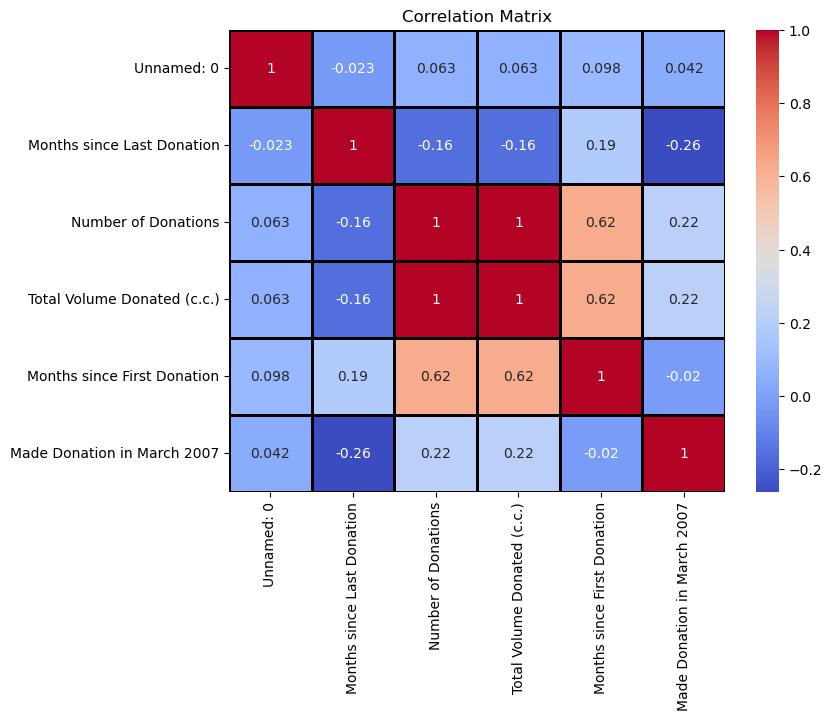

In [13]:
# Set the overall figure size 
plt.figure(figsize=(8, 6)) 

# Select only numerical columns from the dataset for correlation analysis 
numerical_cols = data.select_dtypes(include = ["int", "float"]) 

# Plot a heatmap showing correlations between numerical features 
sns.heatmap(numerical_cols.corr(), annot = True, cmap = "coolwarm", linewidths = 1, linecolor = "black") 

# Add a title to the heatmap 
plt.title("Correlation Matrix") 

plt.show() 

Looks like **Number of Donations** and **Total Volume Donated** are perfectly related, which makes sense since the total volume simply represents the total amount donated across all donations. There’s also a decent positive link between **Months Since First Donation** and **Number of Donations** — people who’ve been part of the program longer tend to donate more. On the other hand, **Months Since Last Donation** shows a slight negative connection with the target variable, meaning recent donors are a bit more likely to donate again. 

In [14]:
# Dropping the unnecessary index column to clean up the dataset 
data.drop(["Unnamed: 0"], axis = 1, inplace = True) 

The column **“Unnamed: 0”** is an automatically generated index column and doesn’t provide any useful information. It doesn’t contribute to analysis or modeling, so it’s being dropped to keep the dataset neat and relevant. 

## Data Preprocessing 
### Data Cleaning (Checking Duplicate Values) 

In [15]:
data.duplicated().sum() # Counting duplicated rows 

153

In [16]:
data.drop_duplicates(inplace = True) # dropping duplicated rows 

## Handling Outliers 

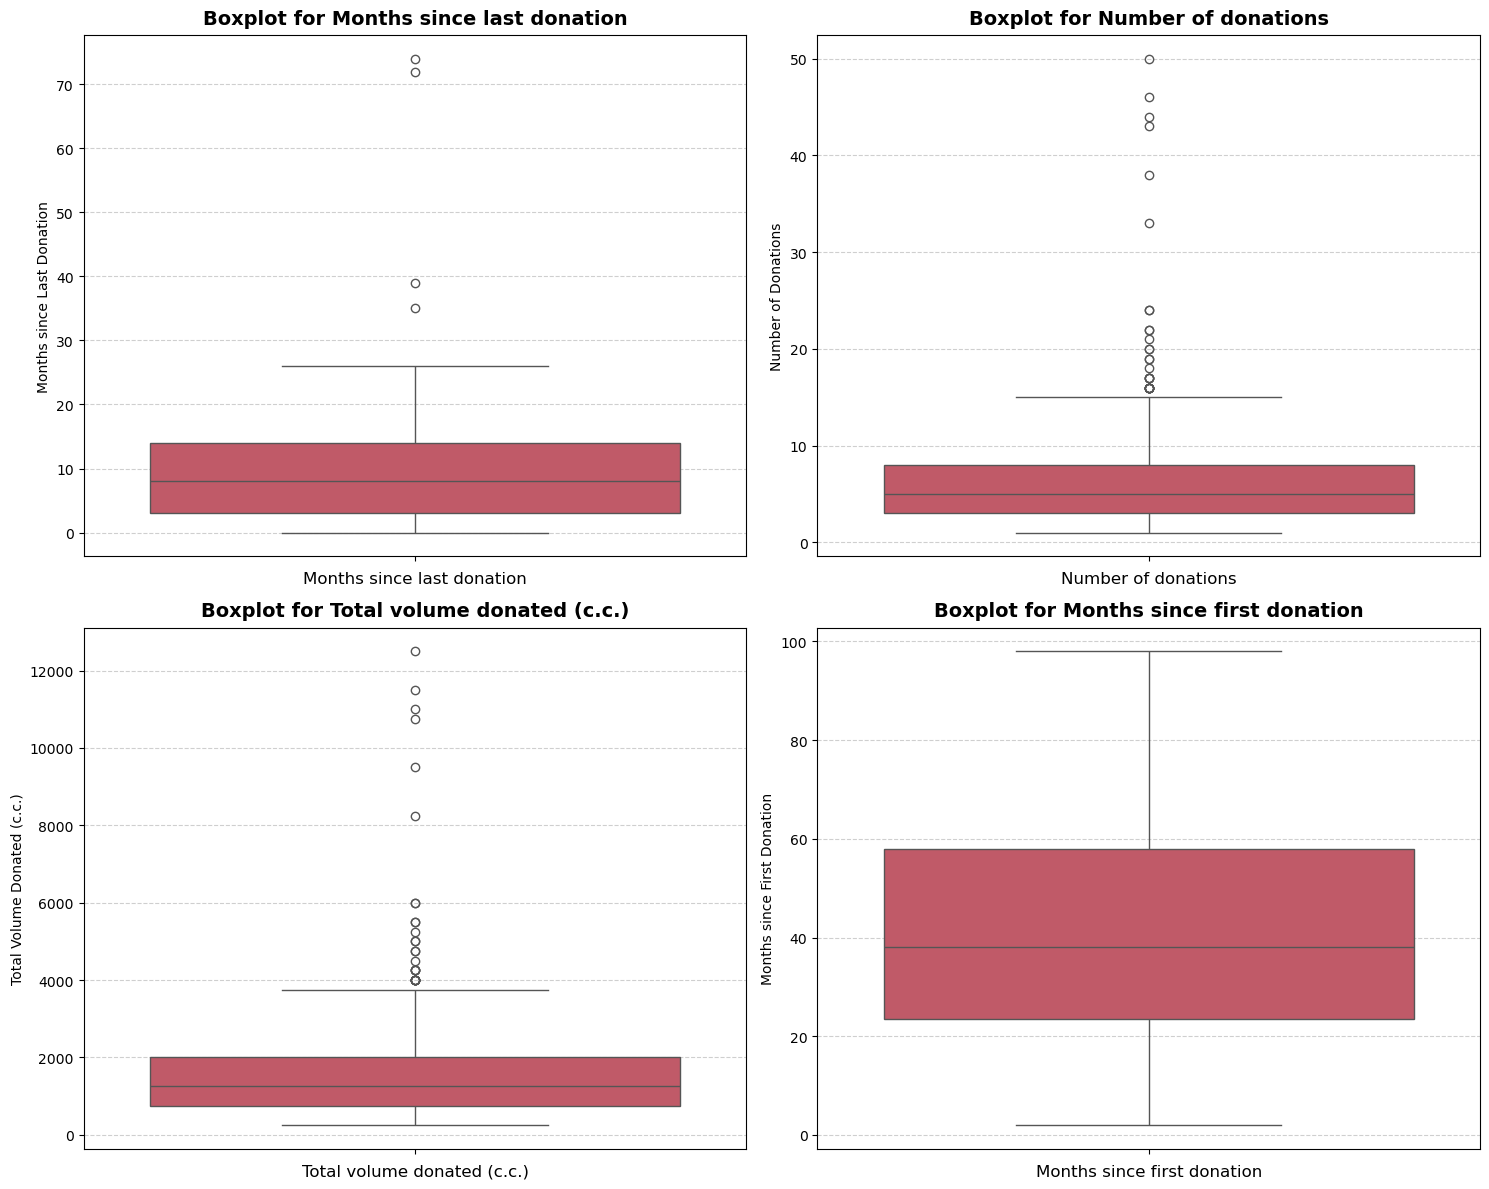

In [17]:
# Set the size of the plots 
plt.figure(figsize = (15, 12)) 

numerical_cols = data.select_dtypes(include = ["int", "float"]).drop("Made Donation in March 2007", axis = 1).columns 

# Boxplots to check for outliers 
for i, col in enumerate(numerical_cols, 1): 
    plt.subplot(2, 2, i)   # 2 rows, 2 columns layout 
    sns.boxplot(data[col], color = "#D1495B") 
    plt.title(f"Boxplot for {col.capitalize()}", fontsize = 14, fontweight = "bold", pad = 8) 
    plt.xlabel(col.capitalize(), fontsize = 12) 
    plt.grid(axis = "y", linestyle = "--", alpha = 0.6) 

plt.tight_layout() 
plt.show() 

The boxplots show that most features contain a few noticeable outliers.  
- **Months Since Last Donation** has a small number of donors who haven’t donated for a very long time.  
- **Number of Donations** and **Total Volume Donated (c.c.)** show several high-value outliers, representing a few very active donors who have donated significantly more than others.  
- **Months Since First Donation** shows a wide spread, meaning the donor base includes both new and long-term participants.  

Overall, the data has some skewness and a few extreme values, which will be handled during preprocessing using the IQR method. 

#### Handling outliers through IQR Method 

In [18]:
# Apply IQR method on selected columns (excluding a few features where extreme values are natural)
for el in data.drop(["Months since First Donation"], axis = 1).columns: 
    Q1 = data[el].quantile(0.25)   # 25th percentile
    Q3 = data[el].quantile(0.75)   # 75th percentile
    IQR = Q3 - Q1                  # Interquartile Range

    # Define acceptable range (Tukey’s rule: 1.5 * IQR)
    lower_boundary = Q1 - 1.5 * IQR
    upper_boundary = Q3 + 1.5 * IQR

    # Replace outliers with median to reduce distortion while preserving distribution
    data.loc[(data[el] < lower_boundary) | (data[el] > upper_boundary), el] = data[el].median() 

Outliers were handled using the **IQR method (Tukey’s rule)** to bring extreme values within a reasonable range.  
Instead of removing them completely, values outside the acceptable limits were **replaced with the median** of each feature.  
This approach helps reduce the impact of extreme points while keeping the overall data distribution stable and consistent. 

## Feature Engineering (New Features) 

In [19]:
data["Donation Rate"] = data["Number of Donations"] / data["Months since First Donation"] 

The new column `DonationRate` tells us how frequently a donor gives blood **on average** since they joined the program.  
It is calculated by dividing the total number of donations by the total months since the first donation.  

- A **higher value** means the donor donates more regularly (e.g., once every few months).  
- A **lower value** means the donor is less consistent or donates rarely.  

This feature helps us capture the **long-term donation behavior** of each donor, showing whether they have been consistently active or not throughout their time in the program. 

In [20]:
data["Loyalty Score"] = data["Number of Donations"] / 1 + data["Months since Last Donation"] 

The new column `LoyaltyScore` gives us a sense of how **engaged and active** a donor is right now.  
It is calculated by dividing the total number of donations by `(1 + Recency)`, where Recency is the number of months since the last donation.  

- A **higher value** means the donor has donated many times **and** has also donated recently.  
- A **lower value** means either the donor has donated very few times, or it has been a long time since their last donation.  

This feature combines both **past behavior (donation history)** and **present activity (recency)** into a single measure.  
It helps us separate donors who are still actively engaged from those who might have dropped out, even if both have donated the same total number of times. 

In [21]:
# Define a custom function for categorizing Recency
def categorize_recency(months):
    if months <= 6:
        return 'Very Recent (≤6 months)'
    elif months <= 12:
        return 'Recent (7–12 months)'
    elif months <= 24:
        return 'Moderately Inactive (13–24 months)'
    else:
        return 'Inactive (>24 months)'

# Apply the function to create a new column
data['RecencyCategory'] = data['Months since Last Donation'].apply(categorize_recency) 

The new column `RecencyCategory` groups donors into categories based on how long it has been since their last donation.  
Instead of just using raw numbers, this feature gives us an easy-to-understand label for each donor’s activity level:

- **Very Recent (≤6 months):** Donated within the last 6 months → highly active donors.  
- **Recent (7–12 months):** Donated within the past year but not very recently → still engaged.  
- **Moderately Inactive (13–24 months):** Haven’t donated for 1–2 years → at risk of becoming inactive.  
- **Inactive (>24 months):** Haven’t donated in more than 2 years → very unlikely to return.  

This feature is useful because it captures **different levels of donor engagement** in a way that’s easy for both the model and humans to interpret.  
It helps us quickly separate donors who are very active from those who are slipping away or already inactive. 

In [22]:
avg_interval = data['Months since First Donation'] / (data['Number of Donations']) 
data['Churn_Risk'] = (data['Months since Last Donation'] > 2 * avg_interval).astype(int) 

The **Churn_Risk** feature helps identify donors who are likely to stop donating.  
It’s created by comparing each donor’s **Months Since Last Donation** with **twice their average donation interval**.  
If a donor hasn’t donated for more than twice their usual gap, they’re marked as `1` (high churn risk), otherwise `0`.  
This gives the model a way to recognize potentially inactive or lost donors. 

In [23]:
high_volume_threshold = data['Total Volume Donated (c.c.)'].quantile(0.9) 
data['High_Volume_Donor'] = (data['Total Volume Donated (c.c.)'] > high_volume_threshold).astype(int) 

This feature marks donors who donated more than the **90th percentile** of total blood volume.  
It helps highlight the top 10% of highly active donors who contribute significantly more than average. 

In [24]:
# Dropping "Total Volume Donated (c.c.)" column 
data.drop(["Total Volume Donated (c.c.)"], axis = 1, inplace = True) 

The column *Total Volume Donated* is perfectly correlated with *Number of Donations* (since Volume = Donations × 250cc).  
To avoid redundancy and multicollinearity, I decided to drop the *Total Volume Donated* column and continue with *Number of Donations*, as it directly reflects donor behavior. 

## Plotting Correlation Matrix to observe how the newly engineered features relate to the existing ones. 

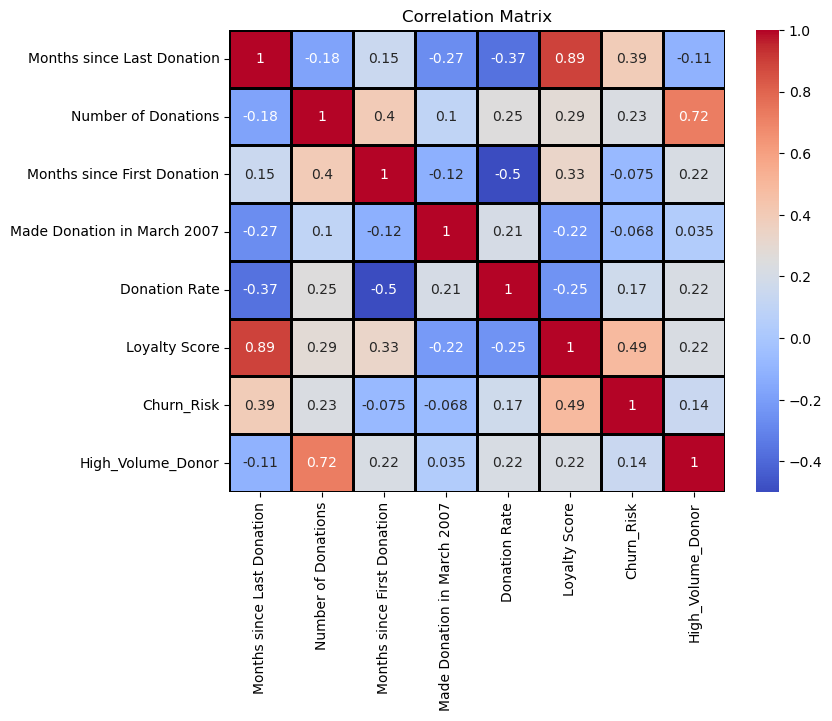

In [25]:
# Set the overall figure size 
plt.figure(figsize=(8, 6)) 

# Select only numerical columns from the dataset for correlation analysis 
numerical_cols = data.select_dtypes(include = ["int", "float"]) 

# Plot a heatmap showing correlations between numerical features 
sns.heatmap(numerical_cols.corr(), annot = True, cmap = "coolwarm", linewidths = 1, linecolor = "black") 

# Add a title to the heatmap 
plt.title("Correlation Matrix") 

plt.show() 

After adding the new features, some strong and meaningful relationships can be seen.  
**Loyalty Score** shows a strong positive correlation with **Months Since Last Donation (0.89)**, which makes sense since it directly depends on how recently a donor gave blood.  
**High Volume Donor** is highly related to **Number of Donations (0.72)**, confirming that frequent donors tend to contribute higher total volumes.  
The **Donation Rate** feature shows a moderate negative relation with **Months Since First Donation**, indicating that newer donors tend to donate at a faster rate initially.  

Overall, these new variables bring out donor behavior patterns more clearly, making the dataset richer and potentially more predictive. 

## Encoding Categorical Variables 

In [26]:
from sklearn.preprocessing import OrdinalEncoder # Importing required library/module 

In [27]:
data.head()  # Showing first few rows for a quick glance at structure 

,Months since Last Donation,Number of Donations,Months since First Donation,Made Donation in March 2007,Donation Rate,Loyalty Score,RecencyCategory,Churn_Risk,High_Volume_Donor
0,2,5,98,1,0.051020,7.0,Very Recent (≤6 months),0,0
1,0,13,28,1,0.464286,13.0,Very Recent (≤6 months),0,1
2,1,5,35,1,0.142857,6.0,Very Recent (≤6 months),0,0
3,2,5,45,1,0.111111,7.0,Very Recent (≤6 months),0,0
4,1,5,77,0,0.064935,6.0,Very Recent (≤6 months),0,0


In [28]:
data["RecencyCategory"].unique() # Checking unique values for "RecencyCategory" column 

array(['Very Recent (≤6 months)', 'Recent (7–12 months)',
       'Moderately Inactive (13–24 months)', 'Inactive (>24 months)'],
      dtype=object)

In [29]:
# Encode RecencyCategory into ordered numerical values using OrdinalEncoder 
ord_enc = OrdinalEncoder(categories = [["Very Recent (≤6 months)", "Recent (7–12 months)", "Moderately Inactive (13–24 months)", "Inactive (>24 months)"]]) 
data["RecencyCategory"] = ord_enc.fit_transform(data[["RecencyCategory"]]) 

## Spliting data into training and testing 

In [30]:
# Split the dataset into features (x) and target variable (y). 
x = data.drop("Made Donation in March 2007", axis = 1) # x contains all the columns except 'Made Donation in March 2007' (the target variable). 
y = data["Made Donation in March 2007"] # y contains only the 'Made Donation in March 2007' column, which is the target variable that the model will predict. 

In [31]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.20) 
# x_train and y_train will be used to train the model, while x_test and y_test will be used for evaluation. 
# The test size is set to 20% of the data (test_size = 0.20), meaning 80% will be used for training. 
# random_state = 42 ensures that the split is reproducible. Using the same random_state will give the same split every time. 

## Scaling 

In [32]:
from sklearn.preprocessing import MinMaxScaler # Importing required library/module 

In [33]:
data.head() # Showing first few rows for a quick glance at structure 

,Months since Last Donation,Number of Donations,Months since First Donation,Made Donation in March 2007,Donation Rate,Loyalty Score,RecencyCategory,Churn_Risk,High_Volume_Donor
0,2,5,98,1,0.051020,7.0,0.0,0,0
1,0,13,28,1,0.464286,13.0,0.0,0,1
2,1,5,35,1,0.142857,6.0,0.0,0,0
3,2,5,45,1,0.111111,7.0,0.0,0,0
4,1,5,77,0,0.064935,6.0,0.0,0,0


In [34]:
 # Selecting continuous features for scaling 
cols_to_scale = ["Months since Last Donation", "Number of Donations", "Months since First Donation", "Loyalty Score"] 

# Scaling/normalizing features 
minmax_scaler = MinMaxScaler() 
x_train[cols_to_scale] = minmax_scaler.fit_transform(x_train[cols_to_scale]) 
x_test[cols_to_scale] = minmax_scaler.transform(x_test[cols_to_scale]) 

## Data Balancing 

In [35]:
# Import the SMOTE (Synthetic Minority Oversampling Technique) class from imbalanced-learn library
from imblearn.over_sampling import SMOTE  

# Initialize the SMOTE object with a fixed random state for reproducibility
smote = SMOTE(random_state = 42)  

# Apply SMOTE to the training data
# This creates synthetic samples of the minority class to balance the dataset
# x_train_smote and y_train_smote will contain the new, balanced training data
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train) 

In [36]:
# Check class distribution before and after applying SMOTE
from collections import Counter  

print("Data before balancing:", Counter(y_train))     # Count of each class before SMOTE 
print("Data after balancing:", Counter(y_train_smote)) # Count of each class after SMOTE 

Data before balancing: Counter({0: 245, 1: 93})
Data after balancing: Counter({0: 245, 1: 245})


Before applying SMOTE, the dataset was imbalanced — there were **245 donors who didn’t donate (class 0)** and only **93 donors who did donate (class 1)**.  
Such imbalance can cause the model to lean toward predicting the majority class more often, which is why balancing the data was necessary. 

## Model Creation and Evaluation 

In [37]:
# Importing various classification models from sklearn to apply different machine learning algorithms for classification tasks.

# LogisticRegression: A linear model used for binary or multiclass classification problems.
from sklearn.linear_model import LogisticRegression 

# DecisionTreeClassifier: A non-linear model that splits data into branches based on feature conditions to make classification decisions.
from sklearn.tree import DecisionTreeClassifier

# RandomForestClassifier & GradientBoostingClassifier: Ensemble models that combine multiple decision trees to improve accuracy and reduce overfitting.
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 

# SVC (Support Vector Classifier): Uses support vector machines to find the optimal decision boundary (hyperplane) that best separates different classes.
from sklearn.svm import SVC 

# KNeighborsClassifier: A non-parametric model that classifies data points based on the majority class of their k-nearest neighbors in the feature space.
from sklearn.neighbors import KNeighborsClassifier 

In [45]:
# Importing evaluation metrics from sklearn to measure model performance.
# - f1_score: balances precision and recall, useful for imbalanced datasets.
# - accuracy_score: measures overall correctness of predictions.
# - precision_score: indicates how many predicted positives were actually correct.
# - recall_score: measures how well the model identifies actual positive cases.
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score 

In [39]:
# Function to evaluate classification models
def evaluate_model(model, x_train_smote, y_train_smote, x_test, y_test):
    # Fit (train) the model
    model.fit(x_train_smote, y_train_smote)
    
    # Predict on training and test data
    y_train_pred = model.predict(x_train_smote)
    y_test_pred = model.predict(x_test)
    
    # Training accuracy
    train_accuracy = accuracy_score(y_train_smote, y_train_pred)
    
    # Test set metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred) 
    recall = recall_score(y_test, y_test_pred) 
    f1 = f1_score(y_test, y_test_pred) 
    
    # Accuracy gap (to check overfitting)
    acc_gap = train_accuracy - test_accuracy
    
    return train_accuracy, test_accuracy, acc_gap, precision, recall, f1 


# Dictionary of classification models
models = { 
    "Logistic Regression": LogisticRegression(random_state=42, class_weight = "balanced"), 
    "Support Vector Machine (SVC)": SVC(random_state=42, class_weight = "balanced"), 
    "KNN": KNeighborsClassifier(), 
    "Decision Tree": DecisionTreeClassifier(random_state=42), 
    "Random Forest": RandomForestClassifier(random_state=42), 
    "Gradient Boosting": GradientBoostingClassifier(random_state=42) 
} 

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    train_acc, test_acc, acc_gap, precision, recall, f1 = evaluate_model(model, x_train_smote, y_train_smote, x_test, y_test)
    
    results[name] = { 
        "Train Accuracy": train_acc, 
        "Test Accuracy": test_acc, 
        "Accuracy Gap": acc_gap, 
        "F1 Score": f1, 
        "Precision": precision, 
        "Recall": recall 
    } 

# Convert results dictionary into DataFrame for easy visualization 
results_df = pd.DataFrame(results).T 
results_df 

,Train Accuracy,Test Accuracy,Accuracy Gap,F1 Score,Precision,Recall
Logistic Regression,0.677551,0.552941,0.124610,0.424242,0.341463,0.56
Support Vector Machine (SVC),0.683673,0.623529,0.060144,0.500000,0.410256,0.64
KNN,0.834694,0.647059,0.187635,0.444444,0.413793,0.48
Decision Tree,0.973469,0.588235,0.385234,0.313725,0.307692,0.32
Random Forest,0.973469,0.658824,0.314646,0.408163,0.416667,0.40
Gradient Boosting,0.895918,0.635294,0.260624,0.474576,0.411765,0.56


## Hyperparameter Tuning 

In [1]:
from sklearn.model_selection import GridSearchCV # Importing required library/module 

### For Support Vector Classifier (SVC): 

In [41]:
# Initialize SVC model with balanced class weights to handle class imbalance
svc_model = SVC(random_state = 42, class_weight = "balanced") 

# Define hyperparameter grid for tuning
svc_param_grid = {
    "C" : [87, 88, 89, 90, 92, 93, 95, 97, 98, 99],       # Regularization parameter
    "kernel" : ["poly"],                                   # Polynomial kernel
    "gamma" : ["scale"],                                   # Kernel coefficient
    "degree" : [4, 5, 8, 10, 11, 12, 13, 14, 15]           # Degrees for polynomial kernel
} 

# Perform Grid Search with 5-fold cross-validation using F1-score as the evaluation metric
svc_gridsearch_model = GridSearchCV(
    estimator = svc_model,
    param_grid = svc_param_grid,
    refit = True,
    verbose = 3,
    scoring = "f1",
    cv = 5,
    n_jobs = -1
) 

# Fit the Grid Search model on the balanced training data
svc_gridsearch_model.fit(x_train_smote, y_train_smote) 

# Display best parameter combination
print("Best params :", svc_gridsearch_model.best_params_)

# Make predictions on both train and test sets
svc_y_pred_tuned = svc_gridsearch_model.predict(x_test) 
svc_y_pred_tuned_train = svc_gridsearch_model.predict(x_train_smote) 

# Evaluate performance using multiple metrics
svc_tuned_metrics = { 
    "Train Accuracy": accuracy_score(y_train_smote, svc_y_pred_tuned_train), 
    "Test Accuracy": accuracy_score(y_test, svc_y_pred_tuned), 
    "Accuracy Gap": accuracy_score(y_train_smote, svc_y_pred_tuned_train) - accuracy_score(y_test, svc_y_pred_tuned), 
    "F1 Score": f1_score(y_test, svc_y_pred_tuned), 
    "Precision": precision_score(y_test, svc_y_pred_tuned), 
    "Recall": recall_score(y_test, svc_y_pred_tuned) 
} 

# Store results in a DataFrame for comparison
svc_tuned_df = pd.DataFrame([svc_tuned_metrics], index=["SVC (Tuned)"]) 
svc_tuned_df 

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best params : {'C': 88, 'degree': 12, 'gamma': 'scale', 'kernel': 'poly'}


,Train Accuracy,Test Accuracy,Accuracy Gap,F1 Score,Precision,Recall
SVC (Tuned),0.793878,0.623529,0.170348,0.529412,0.418605,0.72


### For Random Forest: 

In [42]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(random_state = 42)

# Define parameter grid for hyperparameter tuning
rf_param_grid = {
    "n_estimators": [300, 350, 400, 450, 500],     # Number of trees
    "max_depth": [8, 9, 10, 11, 12, 15],           # Maximum depth of trees
    "min_samples_split": [2, 3, 5],                # Minimum samples to split a node
    "min_samples_leaf": [2, 3, 4, 5],              # Minimum samples at a leaf node
    "max_features": ["log2"]                       # Number of features to consider per split
} 

# Use GridSearchCV to tune parameters using F1 score for evaluation
rf_gridsearch_model = GridSearchCV(
    estimator = rf_model,
    param_grid = rf_param_grid,
    verbose = 3,
    refit = True,
    cv = 3,
    scoring = "f1",
    n_jobs = -1
)

# Fit the tuned Random Forest model on balanced training data
rf_gridsearch_model.fit(x_train_smote, y_train_smote)

# Display best parameter combination found by Grid Search
print("Best params :", rf_gridsearch_model.best_params_)

# Generate predictions for both train and test sets
rf_y_pred_tuned = rf_gridsearch_model.predict(x_test)
rf_y_pred_tuned_train = rf_gridsearch_model.predict(x_train_smote)

# Evaluate model performance with key metrics
rf_tuned_metrics = {
    "Train Accuracy": accuracy_score(y_train_smote, rf_y_pred_tuned_train),
    "Test Accuracy": accuracy_score(y_test, rf_y_pred_tuned),
    "Accuracy Gap": accuracy_score(y_train_smote, rf_y_pred_tuned_train) - accuracy_score(y_test, rf_y_pred_tuned),
    "F1 Score": f1_score(y_test, rf_y_pred_tuned),
    "Precision": precision_score(y_test, rf_y_pred_tuned),
    "Recall": recall_score(y_test, rf_y_pred_tuned)
}

# Store results in a DataFrame for final comparison
rf_tuned_df = pd.DataFrame([rf_tuned_metrics], index=["Random Forest (Tuned)"])
rf_tuned_df 

Fitting 3 folds for each of 360 candidates, totalling 1080 fits


C:\Users\KutbuddinHotel\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best params : {'max_depth': 11, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 350}


,Train Accuracy,Test Accuracy,Accuracy Gap,F1 Score,Precision,Recall
Random Forest (Tuned),0.918367,0.647059,0.271309,0.423077,0.407407,0.44


### For Gradient Boosting: 

In [43]:
# Initialize Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state = 42)

# Define parameter grid for hyperparameter tuning
gb_param_grid = { 
    "n_estimators": [450, 550, 600, 650, 700],        # Number of boosting stages
    "learning_rate": [0.01, 0.02, 0.03, 0.04, 0.05],  # Step size shrinkage
    "max_depth": [2, 3, 4, 5, 7, 8],                  # Maximum depth of trees
    "min_samples_split": [2, 4, 6, 8],                # Minimum samples to split a node
    "min_samples_leaf": [2, 3, 4, 5, 6],              # Minimum samples at a leaf node
    "max_features": ["sqrt", "log2"]                  # Number of features to consider at each split
} 

# Use GridSearchCV to tune parameters using F1 score as the evaluation metric
gb_gridsearch_model = GridSearchCV(
    estimator = gb_model,
    param_grid = gb_param_grid,
    verbose = 3,
    refit = True,
    cv = 3,
    scoring = "f1",
    n_jobs = -1
)

# Fit the model on balanced training data
gb_gridsearch_model.fit(x_train_smote, y_train_smote)

# Display the best parameter combination found
print("Best params :", gb_gridsearch_model.best_params_)

# Generate predictions for both train and test sets
gb_y_pred_tuned = gb_gridsearch_model.predict(x_test)
gb_y_pred_tuned_train = gb_gridsearch_model.predict(x_train_smote)

# Evaluate model performance with key classification metrics
gb_tuned_metrics = {
    "Train Accuracy": accuracy_score(y_train_smote, gb_y_pred_tuned_train),
    "Test Accuracy": accuracy_score(y_test, gb_y_pred_tuned),
    "Accuracy Gap": accuracy_score(y_train_smote, gb_y_pred_tuned_train) - accuracy_score(y_test, gb_y_pred_tuned),
    "F1 Score": f1_score(y_test, gb_y_pred_tuned),
    "Precision": precision_score(y_test, gb_y_pred_tuned),
    "Recall": recall_score(y_test, gb_y_pred_tuned)
}

# Store the tuned model's results in a DataFrame for comparison
gb_tuned_df = pd.DataFrame([gb_tuned_metrics], index=["Gradient Boosting (Tuned)"])
gb_tuned_df 

Fitting 3 folds for each of 6000 candidates, totalling 18000 fits
Best params : {'learning_rate': 0.03, 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 600}


,Train Accuracy,Test Accuracy,Accuracy Gap,F1 Score,Precision,Recall
Gradient Boosting (Tuned),0.95102,0.670588,0.280432,0.44,0.44,0.44


In [44]:
# Combine (stack) the previous results DataFrame with the new tuned model results
results_df = pd.concat([results_df, svc_tuned_df, rf_tuned_df, gb_tuned_df]) 

# Display the final results DataFrame
results_df 

,Train Accuracy,Test Accuracy,Accuracy Gap,F1 Score,Precision,Recall
Logistic Regression,0.677551,0.552941,0.124610,0.424242,0.341463,0.56
Support Vector Machine (SVC),0.683673,0.623529,0.060144,0.500000,0.410256,0.64
KNN,0.834694,0.647059,0.187635,0.444444,0.413793,0.48
Decision Tree,0.973469,0.588235,0.385234,0.313725,0.307692,0.32
Random Forest,0.973469,0.658824,0.314646,0.408163,0.416667,0.40
Gradient Boosting,0.895918,0.635294,0.260624,0.474576,0.411765,0.56
SVC (Tuned),0.793878,0.623529,0.170348,0.529412,0.418605,0.72
Random Forest (Tuned),0.918367,0.647059,0.271309,0.423077,0.407407,0.44
Gradient Boosting (Tuned),0.951020,0.670588,0.280432,0.440000,0.440000,0.44


## 🩸 Model Performance Report 
### Before Hyperparameter Tuning

To begin with, multiple machine learning classification models were implemented to predict whether a donor would donate blood in the next campaign or not.  
The models included **Logistic Regression**, **Support Vector Machine (SVM)**, **K-Nearest Neighbors (KNN)**, **Decision Tree**, **Random Forest**, and **Gradient Boosting Classifier**.  
Each model was trained and tested on the dataset, and performance was evaluated using metrics such as **Accuracy**, **F1-score**, **Precision**, and **Recall**.  

Since the dataset is **imbalanced**, these metrics were preferred over accuracy alone to get a more realistic view of the model’s behavior.

| Model | Train Accuracy | Test Accuracy | Accuracy Gap | F1 Score | Precision | Recall |
|:------|:---------------:|:--------------:|:--------------:|:----------:|:------------:|:---------:|
| Logistic Regression | 0.677 | 0.553 | 0.125 | 0.424 | 0.341 | 0.56 |
| Support Vector Machine | 0.684 | 0.624 | **0.060** | **0.500** | 0.410 | **0.64** |
| KNN | 0.834 | 0.647 | 0.188 | 0.444 | 0.414 | 0.48 |
| Decision Tree | 0.973 | 0.588 | 0.385 | 0.313 | 0.308 | 0.32 |
| Random Forest | 0.973 | 0.659 | 0.314 | 0.408 | 0.417 | 0.40 |
| Gradient Boosting | 0.896 | 0.634 | 0.260 | 0.474 | 0.411 | 0.56 |

#### Observations

- **Tree-based models** like Decision Tree, Random Forest, and Gradient Boosting showed excellent performance on the training data but dropped significantly on the test set.  
  This pattern is a strong sign of **overfitting**, where the model memorizes patterns from the training data but fails to generalize to unseen data.

- **Support Vector Machine (SVM)** achieved the **best balance** between training and test accuracy with a small accuracy gap (0.06), while also maintaining the **highest recall (0.64)**.  
  This means SVM was better at identifying actual donors compared to other models.

- **Logistic Regression** performed decently as a baseline model, but it slightly **underfit** the data, likely because it could not capture non-linear relationships between features.

- **KNN** performed moderately but was sensitive to data imbalance, as it classifies based on distance measures and nearby samples may not represent minority classes well.

Overall, **SVM emerged as the most stable model before tuning**, offering a balanced trade-off between performance and generalization.


### After Hyperparameter Tuning

To further improve the results, hyperparameter tuning was carried out using **GridSearchCV**.  
The evaluation metric for tuning was set to **F1-score**, as it provides a fair balance between **precision** and **recall** — both of which are crucial for an imbalanced dataset like this.  

The tuning focused mainly on models that showed potential before tuning, namely **SVC**, **Random Forest**, and **Gradient Boosting Classifier**.

| Model | Train Accuracy | Test Accuracy | Accuracy Gap | F1 Score | Precision | Recall |
|:------|:---------------:|:--------------:|:--------------:|:----------:|:------------:|:---------:|
| SVC (Tuned) | 0.794 | 0.624 | 0.170 | **0.529** | 0.418 | **0.72** |
| Random Forest (Tuned) | 0.919 | 0.647 | 0.271 | 0.423 | 0.407 | 0.44 |
| Gradient Boosting (Tuned) | 0.951 | 0.671 | 0.280 | 0.440 | 0.440 | 0.44 |

#### Observations

- **SVC (Tuned)** performed the best among all models after tuning.  
  It achieved the **highest recall (0.72)** and **F1-score (0.53)**, meaning it was more effective in identifying actual donors (the positive class).  
  The accuracy gap remained small, showing that the model generalizes well without overfitting.

- **Random Forest (Tuned)** and **Gradient Boosting (Tuned)** showed slight improvements in test accuracy, but their large accuracy gaps suggest they still tend to **overfit** due to the dataset’s limited size.

- Despite being simpler, the **SVC model remained the most stable** even after tuning, confirming that it fits this dataset’s structure better than complex ensemble models.


### Key Insights

- The models generally struggled with mild overfitting due to the **small dataset** and **limited diversity in features**, but hyperparameter tuning helped to stabilize performance.
- **SVC (Tuned)** consistently delivered the **best recall and F1-score**, making it the most suitable model for predicting potential donors.
- Since the goal of this project is to **identify individuals who are likely to donate**, **recall** is more valuable than precision — missing a true donor is costlier than contacting a non-donor.
- Ensemble models such as Random Forest and Gradient Boosting are strong learners but can be too complex for smaller datasets like this, leading to overfitting.

---

### ✅ Final Conclusion

After comparing all models before and after tuning, **the Tuned Support Vector Classifier (SVC)** emerged as the **best-performing and most balanced model**.  
It achieved:
- **Test Accuracy:** 0.62  
- **F1 Score:** 0.53  
- **Recall:** 0.72  
- **AUC Score:** 0.698  

These results show that the model can **fairly distinguish donors from non-donors** while maintaining a good balance between generalization and recall. 

## 🩸 Challenges Faced Report

During the Blood Donation Prediction project, several challenges were encountered at different stages of analysis and model building. Below are the key challenges and how they were addressed:

1. **Imbalanced and Limited Dataset**  
   - The dataset had very few donor cases compared to non-donors, making it difficult for models to learn balanced patterns.  
   - **Solution:** Applied **SMOTE (Synthetic Minority Over-sampling Technique)** to balance the training data. Focused on **F1-score** and **Recall** instead of accuracy for fair model evaluation.

2. **Feature Correlation and Redundancy**  
   - The features “Number of Donations” and “Total Volume Donated” were perfectly correlated, as total volume was derived directly from the number of donations.  
   - **Solution:** Dropped the “Total Volume Donated” column to avoid redundancy and multicollinearity.

3. **Overfitting in Tree-Based Models**  
   - Models like Decision Tree and Random Forest showed very high training accuracy but much lower test accuracy, indicating overfitting.  
   - **Solution:** Used **GridSearchCV** to perform hyperparameter tuning, adjusting parameters like depth, leaf size, and estimators to improve generalization.

4. **Choosing the Right Evaluation Metric**  
   - Accuracy appeared high but was misleading due to class imbalance.  
   - **Solution:** Selected **F1-score** as the primary metric since it balances **precision** and **recall**, giving a better view of true performance.

5. **Small Sample Size and Model Variability**  
   - The small dataset size made models sensitive to data splits, causing minor fluctuations in results.  
   - **Solution:** Implemented **cross-validation** to get more stable and reliable evaluation scores.

**Overall**, the main challenges involved handling imbalance, avoiding overfitting, and selecting appropriate metrics. Tackling these issues step by step improved model stability, interpretability, and confidence in the final results. 